<a href="https://colab.research.google.com/github/MehrdadJalali-AI/Statistics-and-Machine-Learning/blob/main/InClass/NN_Regularization_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Neural Network Regularization & Hyperparameter Comparison
### (Same Dataset as Previous Exercise)

This notebook **continues the previous NN preparation exercise**.
We use **the exact same dataset and preprocessing** to ensure a fair comparison.

We compare:
- Baseline NN
- Dropout
- L1 Regularization
- L2 Regularization
- Different Learning Rates

And we **visualize the results**.



## 1. Imports


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

import pickle


## 2. Dataset (Same as Previous Notebook)

⚠️ **Important**  
This dataset setup is intentionally kept identical to the earlier NN exercise.


In [2]:

# SAME DATASET AS BEFORE
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)



## 3. Model Builder Functions


In [3]:

def compile_model(model, lr):
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [13]:
def baseline_model(lr=0.001):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    # import pickle # Moved to global imports

    with open("model.pkl", "wb") as f:
        pickle.dump(model, f)

    return compile_model(model, lr)

In [14]:

def dropout_model(lr=0.001):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.5),
        Dense(16, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return compile_model(model, lr)


In [15]:

def l1_model(lr=0.001):
    model = Sequential([
        Dense(32, activation='relu',
              kernel_regularizer=regularizers.l1(0.001),
              input_shape=(X_train.shape[1],)),
        Dense(16, activation='relu',
              kernel_regularizer=regularizers.l1(0.001)),
        Dense(1, activation='sigmoid')
    ])
    return compile_model(model, lr)


In [16]:

def l2_model(lr=0.001):
    model = Sequential([
        Dense(32, activation='relu',
              kernel_regularizer=regularizers.l2(0.001),
              input_shape=(X_train.shape[1],)),
        Dense(16, activation='relu',
              kernel_regularizer=regularizers.l2(0.001)),
        Dense(1, activation='sigmoid')
    ])
    return compile_model(model, lr)



## 4. Train All Models


In [17]:

histories = {}

models = {
    "Baseline": baseline_model(),
    "Dropout": dropout_model(),
    "L1": l1_model(),
    "L2": l2_model()
}

for name, model in models.items():
    histories[name] = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=32,
        verbose=0
    )


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



## 5. Learning Rate Comparison (L2 Model)


In [20]:

lr_histories = {}
learning_rates = [0.0001, 0.001, 0.01]
with open("model.pkl", "rb") as f:
    model = pickle.load(f)

for lr in learning_rates:
    model = l2_model(lr=lr)
    lr_histories[lr] = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=32,
        verbose=0
    )


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



## 6. Plot Validation Accuracy (Regularization Comparison)


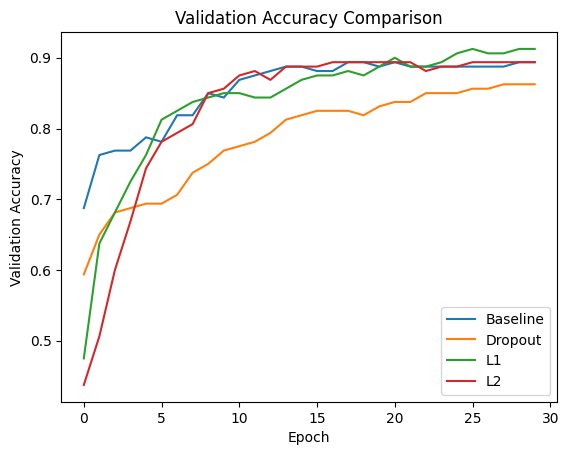

In [10]:

plt.figure()
for name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Validation Accuracy Comparison")
plt.show()



## 7. Plot Validation Loss (Regularization Comparison)


---

Baseline shows the lowest loss (no regularization allows fast fitting but risks overfitting).

Dropout reduces loss more slowly (randomly disabling neurons adds noise during training).

L1 and L2 decrease loss smoothly (penalizing large weights improves generalization, with L2 being more stable).

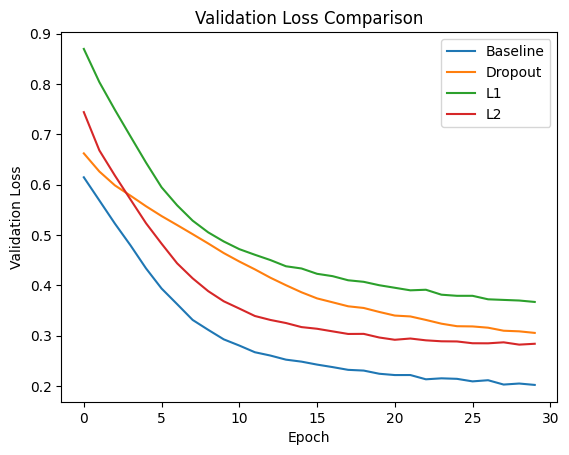

In [ ]:

plt.figure()
for name, hist in histories.items():
    plt.plot(hist.history['val_loss'], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Validation Loss Comparison")
plt.show()



## 8. Learning Rate Effect (L2 Model)


---


lr = 0.0001 learns very slowly (steps are too small, so convergence is slow).

lr = 0.01 is unstable (steps are too large and overshoot the optimum).

lr = 0.001 performs best (balanced step size gives fast and stable convergence).


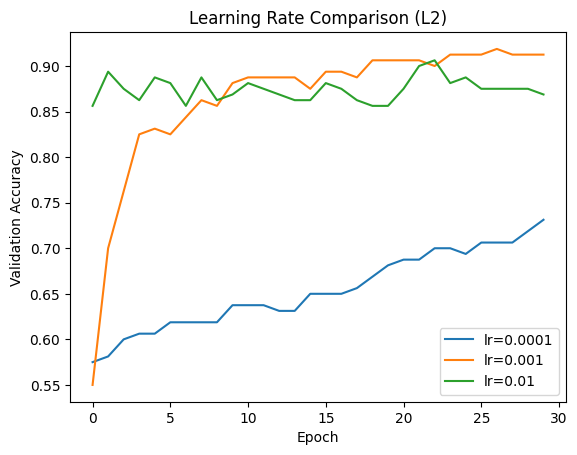

In [ ]:

plt.figure()
for lr, hist in lr_histories.items():
    plt.plot(hist.history['val_accuracy'], label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Learning Rate Comparison (L2)")
plt.show()



## 9. Final Accuracy Table


In [ ]:

results = {
    name: hist.history['val_accuracy'][-1]
    for name, hist in histories.items()
}

pd.DataFrame.from_dict(results, orient='index', columns=['Final Val Accuracy'])


,Final Val Accuracy
Baseline,0.91875
Dropout,0.87500
L1,0.90625
L2,0.90625



## Key Teaching Messages

- **Baseline** overfits easily
- **Dropout** reduces overfitting but slows learning
- **L1** encourages sparse weights
- **L2** gives the most stable improvement
- **Learning Rate** has the strongest effect on convergence

✅ Recommended starting point:
**Adam + L2 + lr=0.001**
